In [1]:
!pip install requests beautifulsoup4 pandas

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
from urllib.parse import urljoin

In [3]:
url = "https://books.toscrape.com/"

response = requests.get(url)

print(response.status_code)

200


In [4]:
soup = BeautifulSoup(response.text, "html.parser")

print(soup.title.text)


    All products | Books to Scrape - Sandbox



In [5]:
books = soup.select("article.product_pod")

print(len(books))

20


In [6]:
book = books[0]

title = book.h3.a["title"]

print(title)

A Light in the Attic


In [7]:
price = book.select_one(".price_color").text

print(price)

Â£51.77


In [8]:
rating = book.select_one(".star-rating")["class"][1]

print(rating)

Three


In [9]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

rating_number = rating_map[rating]

print(rating_number)

3


In [10]:
availability = book.select_one(".availability").get_text(strip=True)

print(availability)

In stock


In [11]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
from urllib.parse import urljoin

url = "https://books.toscrape.com/"

response = requests.get(url)

soup = BeautifulSoup(response.text, "html.parser")

books = soup.select("article.product_pod")

rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

data = []

for book in books:

    title = book.h3.a["title"]

    price = book.select_one(".price_color").text.strip()

    rating_text = book.select_one(".star-rating")["class"][1]
    rating = rating_map[rating_text]

    availability = book.select_one(".availability").get_text(" ", strip=True)

    book_url = urljoin(url, book.h3.a["href"])

    data.append({
        "Book Name": title,
        "Price": price,
        "Rating": rating,
        "Availability": availability,
        "URL": book_url
    })

df = pd.DataFrame(data)

df.head()

,Book Name,Price,Rating,Availability,URL
0,A Light in the Attic,Â£51.77,3,In stock,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,Â£53.74,1,In stock,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,Â£50.10,1,In stock,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,Â£47.82,4,In stock,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,Â£54.23,5,In stock,https://books.toscrape.com/catalogue/sapiens-a...


In [12]:
df.to_csv("books.csv", index=False)

print("Dataset successfully created!")

Dataset successfully created!


In [16]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
from urllib.parse import urljoin

base_url = "https://books.toscrape.com/"

rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

data = []

current_url = base_url

while current_url:

    print("Scraping:", current_url)

    response = requests.get(current_url)

    soup = BeautifulSoup(response.text, "html.parser")

    books = soup.select("article.product_pod")

    for book in books:

        title = book.h3.a["title"]

        price = book.select_one(".price_color").text.strip()

        rating_text = book.select_one(".star-rating")["class"][1]
        rating = rating_map[rating_text]

        availability = book.select_one(
            ".availability"
        ).get_text(" ", strip=True)

        book_url = urljoin(
            current_url,
            book.h3.a["href"]
        )

        data.append({
            "Book Name": title,
            "Price": price,
            "Rating": rating,
            "Availability": availability,
            "URL": book_url
        })

    next_button = soup.select_one("li.next a")

    if next_button:

        current_url = urljoin(
            current_url,
            next_button["href"]
        )

    else:

        current_url = None


df = pd.DataFrame(data)

print("Total books:", len(df))

Scraping: https://books.toscrape.com/
Scraping: https://books.toscrape.com/catalogue/page-2.html
Scraping: https://books.toscrape.com/catalogue/page-3.html
Scraping: https://books.toscrape.com/catalogue/page-4.html
Scraping: https://books.toscrape.com/catalogue/page-5.html
Scraping: https://books.toscrape.com/catalogue/page-6.html
Scraping: https://books.toscrape.com/catalogue/page-7.html
Scraping: https://books.toscrape.com/catalogue/page-8.html
Scraping: https://books.toscrape.com/catalogue/page-9.html
Scraping: https://books.toscrape.com/catalogue/page-10.html
Scraping: https://books.toscrape.com/catalogue/page-11.html
Scraping: https://books.toscrape.com/catalogue/page-12.html
Scraping: https://books.toscrape.com/catalogue/page-13.html
Scraping: https://books.toscrape.com/catalogue/page-14.html
Scraping: https://books.toscrape.com/catalogue/page-15.html
Scraping: https://books.toscrape.com/catalogue/page-16.html
Scraping: https://books.toscrape.com/catalogue/page-17.html
Scraping: 

In [20]:
df.to_csv("books.csv", index=False)

print("books.csv created successfully!")

books.csv created successfully!


In [21]:
df.head()

,Book Name,Price,Rating,Availability,URL
0,A Light in the Attic,Â£51.77,3,In stock,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,Â£53.74,1,In stock,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,Â£50.10,1,In stock,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,Â£47.82,4,In stock,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,Â£54.23,5,In stock,https://books.toscrape.com/catalogue/sapiens-a...


In [22]:
df.shape

(1000, 5)

In [30]:
import pandas as pd

df["Price"] = (
    df["Price"]
    .astype(str)
    .str.extract(r"([0-9]+(?:\.[0-9]+)?)")[0]
    .astype(float)
)

print(df["Price"].head())

0    51.77
1    53.74
2    50.10
3    47.82
4    54.23
Name: Price, dtype: float64


In [32]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Book Name     1000 non-null   str    
 1   Price         1000 non-null   float64
 2   Rating        1000 non-null   int64  
 3   Availability  1000 non-null   str    
 4   URL           1000 non-null   str    
dtypes: float64(1), int64(1), str(3)
memory usage: 39.2 KB
None


In [33]:
print(df.isnull().sum())

Book Name       0
Price           0
Rating          0
Availability    0
URL             0
dtype: int64


In [34]:
print(df.duplicated().sum())

0


In [35]:
average_price = df["Price"].mean()

print("Average Price:", average_price)

Average Price: 35.07035


In [36]:
print("Maximum Price:", df["Price"].max())

Maximum Price: 59.99


In [37]:
print("Minimum Price:", df["Price"].min())

Minimum Price: 10.0


In [38]:
print("Average Rating:", df["Rating"].mean())

Average Rating: 2.923


In [39]:
rating_count = df["Rating"].value_counts().sort_index()

print(rating_count)

Rating
1    226
2    196
3    203
4    179
5    196
Name: count, dtype: int64


In [41]:
df.sort_values(
    "Price",
    ascending=False
).head(10)

,Book Name,Price,Rating,Availability,URL
648,The Perfect Play (Play by Play #1),59.99,3,In stock,https://books.toscrape.com/catalogue/the-perfe...
617,Last One Home (New Beginnings #1),59.98,3,In stock,https://books.toscrape.com/catalogue/last-one-...
860,Civilization and Its Discontents,59.95,2,In stock,https://books.toscrape.com/catalogue/civilizat...
560,The Barefoot Contessa Cookbook,59.92,5,In stock,https://books.toscrape.com/catalogue/the-baref...
366,The Diary of a Young Girl,59.90,3,In stock,https://books.toscrape.com/catalogue/the-diary...
657,The Bone Hunters (Lexy Vaughan & Steven Macaul...,59.71,3,In stock,https://books.toscrape.com/catalogue/the-bone-...
133,Thomas Jefferson and the Tripoli Pirates: The ...,59.64,1,In stock,https://books.toscrape.com/catalogue/thomas-je...
387,Boar Island (Anna Pigeon #19),59.48,3,In stock,https://books.toscrape.com/catalogue/boar-isla...
549,The Man Who Mistook His Wife for a Hat and Oth...,59.45,4,In stock,https://books.toscrape.com/catalogue/the-man-w...
393,The Improbability of Love,59.45,1,In stock,https://books.toscrape.com/catalogue/the-impro...


In [42]:
df.groupby("Rating")["Price"].mean()

Rating
1    34.561195
2    34.810918
3    34.692020
4    36.093296
5    35.374490
Name: Price, dtype: float64

In [45]:
import matplotlib.pyplot as plt

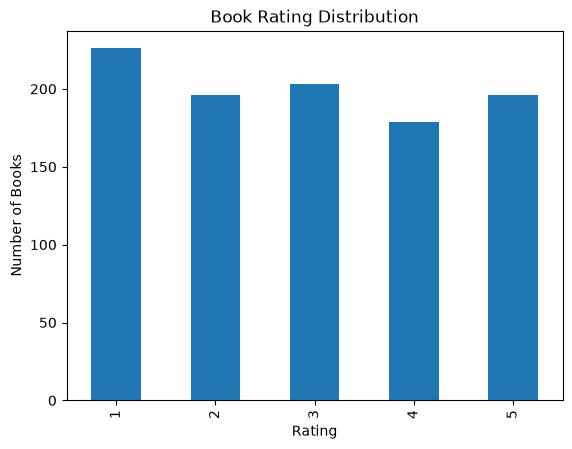

In [46]:
df["Rating"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Book Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.show()

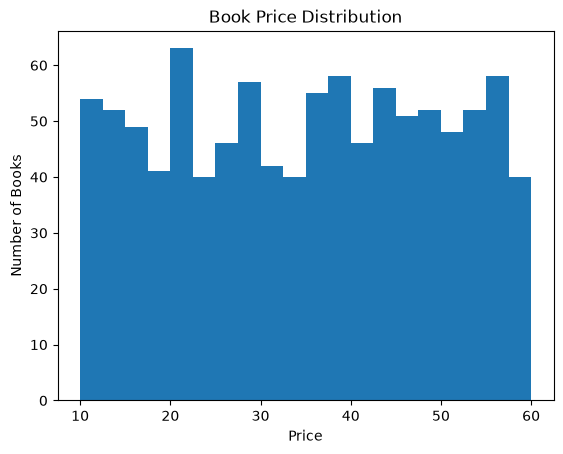

In [47]:
df["Price"].plot(
    kind="hist",
    bins=20
)

plt.title("Book Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Books")
plt.show()

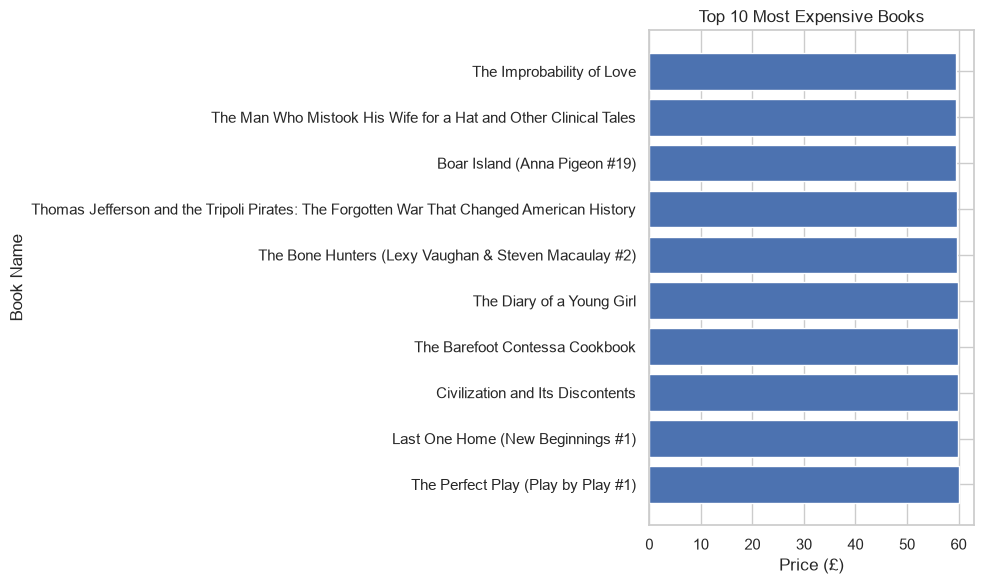

In [50]:
top_books = df.sort_values(
    "Price",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_books["Book Name"],
    top_books["Price"]
)

plt.title("Top 10 Most Expensive Books")
plt.xlabel("Price (£)")
plt.ylabel("Book Name")

plt.tight_layout()
plt.show()